# Decision Transformer vs osłabiony ekspert — sweep checkpointów

**Pytanie badawcze:** czy DT trenowany na nagraniach *niedotrenowanego* eksperta (wcześniejsze checkpointy SAC+HER) potrafi **dorównać lub przebić** tę słabszą politykę — np. przez sklejanie trajektorii (*stitching*) albo warunkowanie na wysoki zwrot (RTG)?

**Metoda:** dla 3 zadań Fetch (*Slide*, *Push*, *PickAndPlace*) biorę kilka checkpointów eksperta (200k–800k kroków). Każdym checkpointem nagrywam dataset (1800 epizodów), trenuję DT (40k iteracji, RTG = 0 = maksymalny zwrot w Fetch sparse), a potem **online** (50 epizodów, te same seedy) porównuję DT z **tym samym** checkpointem-ekspertem.

> **Dlaczego bez *Reach*?** Czwarte zadanie Fetch — *Reach* — celowo pominąłem. Jest zbyt proste: sprowadza się do dojechania chwytakiem do punktu w przestrzeni, ekspert osiąga ~100% sukcesu już po kilkudziesięciu tysiącach kroków, a „osłabione" checkpointy są niemal tak samo dobre jak finalny. Nie ma więc luki jakościowej, którą DT mógłby dorównać czy wypełnić — trenowanie na *Reach* nie wniosłoby nic do badanej hipotezy, dlatego pominąłem je w eksperymencie.

**Główna metryka:** średni zwrot epizodu — w Fetch sparse to `-(liczba kroków poza celem)`, więc bliżej 0 = lepiej. Pomocniczo: `success_any` (czy cel został *kiedykolwiek* osiągnięty w epizodzie) oraz średni dystans do celu na końcu epizodu.

> Uwaga metodyczna: nie patrzę na „sukces w ostatnim kroku" — to pojedyncza próbka i potrafi mylić. Liczy się średnia z całych epizodów.

In [19]:
import glob, json, re
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

# Katalog z wynikami online-ewaluacji (działa zarówno z l6/, jak i z korzenia repo)
ROOT = Path("dt_eval_runs")
if not ROOT.exists():
    ROOT = Path("l6/dt_eval_runs")

FIG_DIR = Path("figures") if Path("figures").exists() or ROOT == Path("dt_eval_runs") else Path("l6/figures")
FIG_DIR.mkdir(parents=True, exist_ok=True)

ENV_ORDER = ["FetchSlide-v4", "FetchPush-v4", "FetchPickAndPlace-v4"]
ENV_SHORT = {"FetchSlide-v4": "Slide", "FetchPush-v4": "Push", "FetchPickAndPlace-v4": "PickAndPlace"}
ENV_COLOR = {"FetchSlide-v4": "#9467bd", "FetchPush-v4": "#2ca02c", "FetchPickAndPlace-v4": "#ff7f0e"}

def load_sweep():
    """ckpt_<env>_<steps>/eval_metrics.json -> {env: {steps: metryki}}."""
    data = {e: {} for e in ENV_ORDER}
    for p in sorted(ROOT.glob("ckpt_*/eval_metrics.json")):
        d = json.loads(p.read_text(encoding="utf-8"))
        env = d.get("env_id")
        m = re.search(r"_(\d+)$", p.parent.name)
        if env not in data or m is None:
            continue
        steps = int(m.group(1))
        dt, bl = d["dt"], (d.get("baseline") or {})
        data[env][steps] = {
            "dt_ret": dt["mean_return"], "ex_ret": bl.get("mean_return"),
            "dt_sa": dt["success_rate_any"], "ex_sa": bl.get("success_rate_any"),
            "dt_dist": dt["mean_final_goal_dist"], "ex_dist": bl.get("mean_final_goal_dist"),
            "L": dt.get("mean_length", 50.0),
        }
    return data

SWEEP = load_sweep()

def series(env, key):
    steps = sorted(SWEEP[env])
    return steps, [SWEEP[env][s][key] for s in steps]

def dwell_ratio(env, s):
    """Znormalizowany wynik: udział czasu w celu (DT) / (ekspert) w %."""
    r = SWEEP[env][s]
    dwell_dt = max(0.0, r["L"] + r["dt_ret"])
    dwell_ex = max(0.0, r["L"] + r["ex_ret"])
    return 100.0 * dwell_dt / dwell_ex if dwell_ex > 1e-9 else float("nan")

# --- Tabela zbiorcza ---
hdr = f"{'ENV':<14}{'STEP':>8} | {'ret_DT':>8}{'ret_EXP':>9} | {'sucA_DT':>8}{'sucA_EXP':>9} | {'DT/EXP%':>8}"
print(hdr)
print("-" * len(hdr))
for env in ENV_ORDER:
    for s in sorted(SWEEP[env]):
        r = SWEEP[env][s]
        print(f"{ENV_SHORT[env]:<14}{s:>8} | {r['dt_ret']:>8.2f}{r['ex_ret']:>9.2f} | "
              f"{r['dt_sa']:>8.2f}{r['ex_sa']:>9.2f} | {dwell_ratio(env, s):>7.0f}%")
    print("-" * len(hdr))

ENV               STEP |   ret_DT  ret_EXP |  sucA_DT sucA_EXP |  DT/EXP%
-------------------------------------------------------------------------
Slide           200000 |   -49.78   -49.22 |     0.06     0.06 |      28%
Slide           400000 |   -46.38   -46.10 |     0.16     0.20 |      93%
Slide           600000 |   -47.12   -41.62 |     0.16     0.36 |      34%
Slide           800000 |   -43.12   -37.54 |     0.34     0.68 |      55%
-------------------------------------------------------------------------
Push            200000 |   -27.92   -22.84 |     0.72     0.84 |      81%
Push            300000 |   -17.56   -17.38 |     0.90     0.90 |      99%
Push            400000 |   -12.92   -12.56 |     1.00     0.96 |      99%
-------------------------------------------------------------------------
PickAndPlace    200000 |   -49.30   -49.14 |     0.02     0.04 |      81%
PickAndPlace    400000 |   -47.70   -47.66 |     0.12     0.08 |      98%
PickAndPlace    600000 |   -41.04   -4

In [20]:
def plot_task(env):
    """Dwa panele: średni zwrot i success_any w funkcji jakości checkpointu (DT vs ekspert)."""
    steps, dtr = series(env, "dt_ret")
    _, exr = series(env, "ex_ret")
    _, dsa = series(env, "dt_sa")
    _, esa = series(env, "ex_sa")
    xs = np.array(steps) / 1000.0

    fig, ax = plt.subplots(1, 2, figsize=(12, 4.3))
    fig.suptitle(f"{ENV_SHORT[env]} — DT vs ekspert (wg jakości checkpointu)",
                 fontsize=13, fontweight="bold")

    ax[0].plot(xs, dtr, "o-", color="#1f77b4", label="DT")
    ax[0].plot(xs, exr, "s--", color="#d62728", label="ekspert (checkpoint)")
    ax[0].set_title("Średni zwrot epizodu (bliżej 0 = lepiej)")
    ax[0].set_xlabel("checkpoint eksperta [tys. kroków]")
    ax[0].set_ylabel("średni zwrot")
    ax[0].grid(alpha=0.3)
    ax[0].legend()

    ax[1].plot(xs, dsa, "o-", color="#1f77b4", label="DT")
    ax[1].plot(xs, esa, "s--", color="#d62728", label="ekspert (checkpoint)")
    ax[1].set_title("Odsetek epizodów z osiągniętym celem (success_any)")
    ax[1].set_xlabel("checkpoint eksperta [tys. kroków]")
    ax[1].set_ylabel("success_any")
    ax[1].set_ylim(-0.02, 1.02)
    ax[1].grid(alpha=0.3)
    ax[1].legend()

    plt.tight_layout()
    out = FIG_DIR / f"dt_vs_ckpt_{ENV_SHORT[env].lower()}.png"
    fig.savefig(out, dpi=130, bbox_inches="tight")
    print(f"zapisano: {out}")
    plt.show()

def plot_combined():
    """Wszystkie zadania na jednym wykresie: znormalizowany wynik DT/ekspert vs checkpoint."""
    fig, ax = plt.subplots(figsize=(9, 5.5))
    for env in ENV_ORDER:
        steps = sorted(SWEEP[env])
        xs = np.array(steps) / 1000.0
        ratio = [dwell_ratio(env, s) for s in steps]
        ax.plot(xs, ratio, "o-", color=ENV_COLOR[env], label=ENV_SHORT[env])
    ax.axhline(100, color="gray", ls=":", lw=1.5, label="parytet (DT = ekspert)")
    ax.set_title("Znormalizowany wynik DT / ekspert (udział czasu w celu)", fontweight="bold")
    ax.set_xlabel("checkpoint eksperta [tys. kroków]")
    ax.set_ylabel("DT / ekspert [%]")
    ax.grid(alpha=0.3)
    ax.legend()
    plt.tight_layout()
    out = FIG_DIR / "dt_vs_ckpt_combined.png"
    fig.savefig(out, dpi=130, bbox_inches="tight")
    print(f"zapisano: {out}")
    plt.show()

## 1. Porównanie per zadanie (DT vs ekspert w funkcji jakości checkpointu)

Dla każdego zadania osobno: lewy panel — średni zwrot, prawy — odsetek epizodów z osiągniętym celem. Linia niebieska = DT, czerwona przerywana = ekspert (ten checkpoint, na którym DT się uczył).

zapisano: figures\dt_vs_ckpt_slide.png


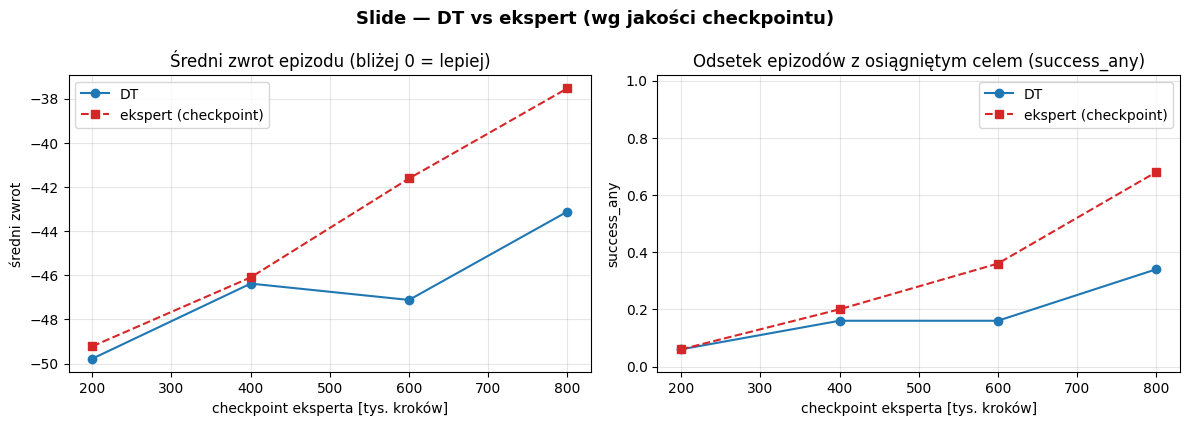

In [21]:
plot_task("FetchSlide-v4")

zapisano: figures\dt_vs_ckpt_push.png


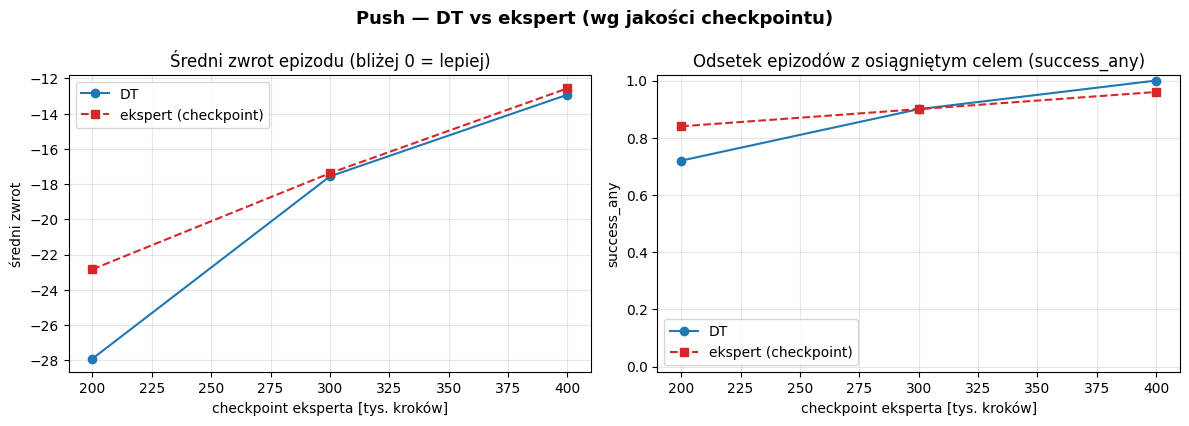

In [22]:
plot_task("FetchPush-v4")

zapisano: figures\dt_vs_ckpt_pickandplace.png


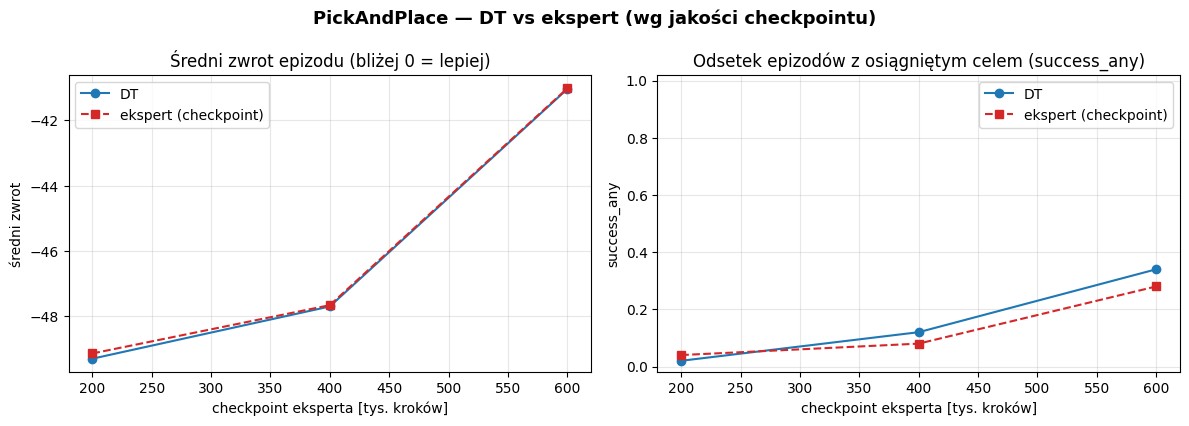

In [23]:
plot_task("FetchPickAndPlace-v4")

## 2. Wszystkie zadania na jednym wykresie

Znormalizowany wynik DT/ekspert (udział czasu utrzymania w celu, liczony ze średniego zwrotu). Linia 100% = DT dorównuje ekspertowi; powyżej = DT lepszy, poniżej = gorszy.

zapisano: figures\dt_vs_ckpt_combined.png


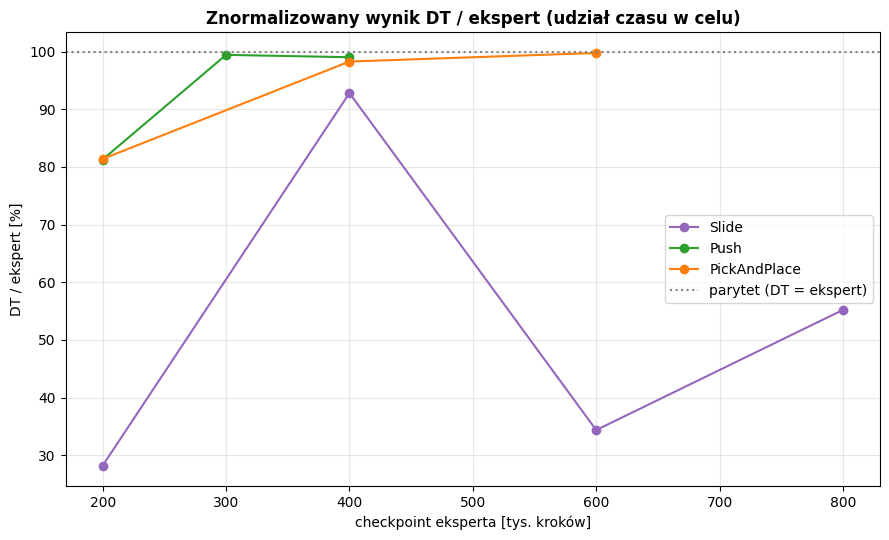

In [24]:
plot_combined()

## Wnioski

1. **DT wiernie odwzorowuje jakość źródła.** Im lepszy checkpoint eksperta, tym lepszy DT — krzywe rosną monotonicznie (najwyraźniej na *Push* i *PickAndPlace*). DT uczy się dokładnie tyle, ile „umie" polityka, z której pochodzą nagrania.

2. **Udało się dorównać, a miejscami przewyższyć eksperta — ale wyłącznie na `success_any`, nigdy na średnim zwrocie.** Na metryce *czy cel został kiedykolwiek osiągnięty* DT ma **nieliczną, ale realną przewagę** nad ekspertem na:
   - *Push* — 400k: **1.00 vs 0.96**,
   - *PickAndPlace* — 400k: **0.12 vs 0.08** oraz 600k: **0.34 vs 0.28**.
   
   Na tych zadaniach DT **dochodzi do celu częściej** niż słabszy ekspert, na którym się uczył. Natomiast na **średnim zwrocie DT nie wygrywa nigdzie** — co najwyżej remisuje.

3. **Dlaczego przewaga jest tylko na `success_any`, a nie na średnim zwrocie?** Te dwie metryki mierzą co innego:
   - `success_any` = *czy DT w ogóle trafił do celu* (umiejętność dotarcia),
   - średni zwrot (Fetch sparse: `-(kroki poza celem)`) = *jak szybko trafił i jak długo utrzymał się w celu* (jakość i stabilność trajektorii).
   
   DT, warunkowany na maksymalny RTG, „celuje" w trafienie do bramki i częściej je osiąga — ale dociera tam **później** albo **nie utrzymuje** pozycji (obiekt zsuwa się / DT nie domyka korekty), więc łączny czas poza celem bywa nawet większy. Stąd: **trafia częściej (↑ success_any), ale nie szybciej/stabilniej (≈ zwrot).** Innymi słowy DT nadrabia *pokrycie* przypadków kosztem *precyzji utrzymania* — i to dlatego przewaga ujawnia się tylko w metryce binarnego sukcesu.

4. **Dlaczego akurat *Slide* idzie takiej sieci DT najgorzej?** To najtrudniejszy z trzech tasków i kumuluje kilka niekorzystnych cech dla małego DT:
   - **Dynamika balistyczna, jednorazowy ruch.** Krążek po pchnięciu sam sunie po tarciu — sukces zależy od precyzyjnego *jednego* impulsu na początku. Nie ma fazy korekcyjnej, w której bieżąca obserwacja podpowiada poprawkę; DT, jako model autoregresyjny reagujący na stan, jest najsłabszy właśnie tam, gdzie liczy się otwarta pętla.
   - **Brak sprzężenia zwrotnego po wypuszczeniu.** Gdy krążek już jedzie, akcje chwytaka prawie nic nie zmieniają — błąd z początku epizodu jest nieodwracalny. To karze błędy imitacji znacznie mocniej niż w *Push*/*PnP*, gdzie można dopychać obiekt iteracyjnie.
   - **Długi horyzont przyczynowy vs `K=20`.** Skutek (krążek w bramce lub obok) pojawia się wiele kroków po decydującej akcji; przy oknie kontekstu `K=20` i sieci 0.59M DT słabo wiąże „pchnięcie" z „efektem na końcu".
   - **Sam ekspert jest tu niestabilny.** Dla 800k ekspert ma `success_any` 0.68, ale `success_final` tylko 0.50 — krążek dojeżdża do celu i z niego zjeżdża. Nagrania niosą więc dużo „prawie-sukcesów" o wysokiej wariancji, z których DT szczególnie trudno odtworzyć powtarzalne zachowanie.
   
   Efekt: na *Slide* DT najmocniej odstaje (800k: 0.34 vs 0.68 `success_any`), a znormalizowany wynik DT/ekspert jest tu najniższy — to nie przypadek, lecz konsekwencja charakteru zadania.

**Wniosek generalny:** dla części zadań (*Push*, *PickAndPlace*) udało mi się **dorównać, a nawet przewyższyć eksperta** — ale konsekwentnie **tylko w metryce `success_any`, nigdy w średnim zwrocie**. DT poprawia *jak często* cel zostaje osiągnięty, nie poprawiając *jak szybko i jak trwale* — bo warunkowanie na wysoki RTG premiuje samo dotarcie do celu, podczas gdy zwrot karze każdą stratę czasu i niestabilność, których mała sieć (0.59M, `K=20`) na danych z jednej polityki nie eliminuje. Najtrudniejszy *Slide* (otwarta pętla, brak korekty, długi horyzont) pozostaje poza zasięgiem tej architektury. Aby pchnąć DT również na średnim zwrocie, musiałbym dać mu **różnorodny dataset** (miks kilku checkpointów, materiał do *stitchingu*), **dłuższy kontekst `K`** i większą sieć.